<a href="https://colab.research.google.com/github/Sai-nikhil2k5/Cardio-Pulmonary-disease-detection-by-sounds/blob/main/hear_lung_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'GDToT',
 'AppDrive',
 '1086289 _Twitter accounts.xlsx',
 'yaswanthyashuuuu-20240111-0002.jpg',
 'IMG_20240128_191522.jpg',
 'A001C00172_240310_7MLF~3.mp4',
 'Screenshot_20240311_135630.jpg',
 'AVL TREES.pdf',
 'Classroom',
 'Screenshot_20240910_170743 (1).jpg',
 'Screenshot_20240910_170743.jpg',
 'Path finder-WPS Office.docx',
 'IMG-20231103-WA0009.jpg',
 'IMG_20240909_211011.jpg',
 'IMG_20241019_200053.jpg',
 'train',
 'valid',
 'VWCC',
 'Screenshot (32).png',
 'Screenshot (34).png',
 'Sai nikhil resume.pdf',
 'New PDF Document-WPS Office (1).pdf',
 'New PDF Document-WPS Office.pdf',
 'OfferLetter.pdf',
 'Screenshot_2025-05-11-22-03-58-13_6012fa4d4ddec268fc5c7112cbb265e7.jpg',
 'Untitled document.gdoc',
 'Screenshot_2025-05-26-12-54-00-33_1c337646f29875672b5a61192b9010f9.jpg',
 'Screenshot_2025-05-26-12-54-13-74_af7491585f6f34cc867e22eb0718f0bc.jpg',
 'Vizag_GreenMask.tif',
 'VizagGreenVisualized.tif',
 'Screenshot_2025-06-07-20-39-12-01_944a2809ea1b4cda6ef12d1db

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Dataset.v2.zip"
extract_path = "/content/Dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted!")

Extracted!


In [ ]:
DATA_PATH = "/content/Dataset/Dataset.v2"

print(os.listdir(DATA_PATH))

['Mix1', 'Mix2', 'Mix.csv', 'HS', 'HS.csv', 'Mix3', 'LS.csv', 'LS']


In [ ]:
import pandas as pd

DATA_PATH = "/content/Dataset/Dataset.v2"

df_hs = pd.read_csv(DATA_PATH + "/HS.csv")
df_ls = pd.read_csv(DATA_PATH + "/LS.csv")
df_mix = pd.read_csv(DATA_PATH + "/Mix.csv")

In [ ]:
df_hs_new = pd.DataFrame({
    "file": df_hs["Heart Sound ID"],
    "heart_label": df_hs["Heart Sound Type"],
    "lung_label": "None",
    "source": "heart"
})

df_ls_new = pd.DataFrame({
    "file": df_ls["Lung Sound ID"],
    "heart_label": "None",
    "lung_label": df_ls["Lung Sound Type"],
    "source": "lung"
})

df_mix3 = pd.DataFrame({
    "file": df_mix["Mixed Sound ID"],
    "heart_label": df_mix["Heart Sound Type"],
    "lung_label": df_mix["Lung Sound Type"],
    "source": "mix3"
})

df_mix1 = pd.DataFrame({
    "file": df_mix["Heart Sound ID"],
    "heart_label": df_mix["Heart Sound Type"],
    "lung_label": "None",
    "source": "mix1"
})

df_mix2 = pd.DataFrame({
    "file": df_mix["Lung Sound ID"],
    "heart_label": "None",
    "lung_label": df_mix["Lung Sound Type"],
    "source": "mix2"
})

df = pd.concat([
    df_hs_new,
    df_ls_new,
    df_mix1,
    df_mix2,
    df_mix3
], ignore_index=True)

print("Total samples:", len(df))


Total samples: 535


In [ ]:
def get_path(row):
    if row["source"] == "heart":
        return f"{DATA_PATH}/HS/HS/{row['file']}.wav"

    elif row["source"] == "lung":
        return f"{DATA_PATH}/LS/LS/{row['file']}.wav"

    elif row["source"] == "mix1":
        return f"{DATA_PATH}/Mix1/{row['file']}.wav"

    elif row["source"] == "mix2":
        return f"{DATA_PATH}/Mix2/{row['file']}.wav"

    else:  # mix3
        return f"{DATA_PATH}/Mix3/{row['file']}.wav"

df["path"] = df.apply(get_path, axis=1)

# check
print(df["path"].head())

0      /content/Dataset/Dataset.v2/HS/HS/F_N_RC.wav
1      /content/Dataset/Dataset.v2/HS/HS/F_N_LC.wav
2    /content/Dataset/Dataset.v2/HS/HS/M_N_RUSB.wav
3    /content/Dataset/Dataset.v2/HS/HS/F_N_LUSB.wav
4    /content/Dataset/Dataset.v2/HS/HS/F_N_LLSB.wav
Name: path, dtype: object


In [ ]:
import os

print(os.path.exists(df.iloc[12]["path"]))

True


In [ ]:
from sklearn.preprocessing import LabelEncoder

heart_encoder = LabelEncoder()
lung_encoder = LabelEncoder()

df["heart_encoded"] = heart_encoder.fit_transform(df["heart_label"])
df["lung_encoded"] = lung_encoder.fit_transform(df["lung_label"])

print(df[["heart_label", "heart_encoded"]].drop_duplicates())
print(df[["lung_label", "lung_encoded"]].drop_duplicates())

              heart_label  heart_encoded
0                  Normal              7
6   Late Diastolic Murmur              3
7     Mid Systolic Murmur              5
11   Late Systolic Murmur              4
13    Atrial Fibrillation              1
14                     S4              9
15  Early Systolic Murmur              2
22                     S3              8
28            Tachycardia             10
33               AV Block              0
50                   None              6
         lung_label  lung_encoded
0              None             2
50           Normal             3
56      Pleural Rub             4
58          Rhonchi             5
59         Wheezing             6
60    Fine Crackles             1
62  Coarse Crackles             0


In [ ]:
import librosa
import numpy as np
from skimage.transform import resize

def extract_spectrogram(file_path):

    try:
        audio, sr = librosa.load(file_path, sr=22050)

        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=128
        )

        mel_spec_db = librosa.power_to_db(
            mel_spec,
            ref=np.max
        )

        mel_spec_resized = resize(
            mel_spec_db,
            (128, 128),
            anti_aliasing=True
        )

        return mel_spec_resized

    except:
        return None

In [ ]:
spec = extract_spectrogram(df.iloc[0]["path"])

print(spec.shape)

(128, 128)


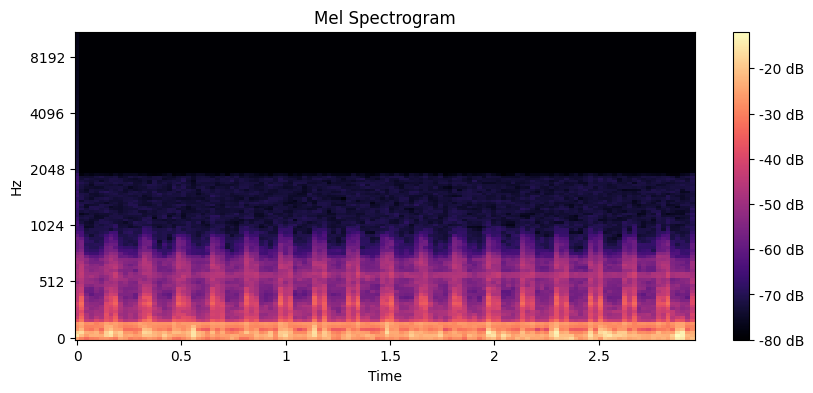

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10,4))

librosa.display.specshow(
    spec,
    sr=22050,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")

plt.show()

In [ ]:
X_cnn = []
y_cnn_labels = []

for _, row in df.iterrows():

    # ONLY keep rows with REAL heart labels
    if row["heart_label"] != "None":

        spec = extract_spectrogram(row["path"])

        if spec is not None:

            X_cnn.append(spec)
            y_cnn_labels.append(row["heart_label"])

In [ ]:
from sklearn.preprocessing import LabelEncoder

cnn_encoder = LabelEncoder()

y_cnn = cnn_encoder.fit_transform(y_cnn_labels)

In [ ]:
print(cnn_encoder.classes_)
print(len(cnn_encoder.classes_))

['AV Block' 'Atrial Fibrillation' 'Early Systolic Murmur'
 'Late Diastolic Murmur' 'Late Systolic Murmur' 'Mid Systolic Murmur'
 'Normal' 'S3' 'S4' 'Tachycardia']
10


In [ ]:
X_cnn = np.array(X_cnn)
y_cnn = np.array(y_cnn)

X_cnn = X_cnn[..., np.newaxis]
print(X_cnn.shape)

(340, 128, 128, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)

In [ ]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train = (X_train - X_train.mean()) / X_train.std()
X_test = (X_test - X_test.mean()) / X_test.std()

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [ ]:
model = Sequential([

    tf.keras.layers.Input(shape=(128,128,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Dropout(0.3),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.4),

    Dense(len(cnn_encoder.classes_), activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,354 (12.61 MB)

 Trainable params: 3,305,354 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 282ms/step - accuracy: 0.0699 - loss: 2.3549 - val_accuracy: 0.1324 - val_loss: 2.3018
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 313ms/step - accuracy: 0.0699 - loss: 2.2937 - val_accuracy: 0.1029 - val_loss: 2.2848
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 261ms/step - accuracy: 0.1324 - loss: 2.2619 - val_accuracy: 0.1618 - val_loss: 2.2148
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 317ms/step - accuracy: 0.1985 - loss: 2.1574 - val_accuracy: 0.1912 - val_loss: 2.2102
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 246ms/step - accuracy: 0.2647 - loss: 2.0751 - val_accuracy: 0.3824 - val_loss: 1.9647
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 290ms/step - accuracy: 0.3676 - loss: 1.7616 - val_accuracy: 0.4706 - val_loss: 1.7269
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 310ms/step - accuracy: 0.4669 - loss: 1.4786 - val_accuracy: 0.5882 - val_loss: 1.3755
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.6066 - loss: 1.1874 - val_accu

In [ ]:
model.save("heart_cnn_model.keras")

In [ ]:
from google.colab import files

files.download("heart_cnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step


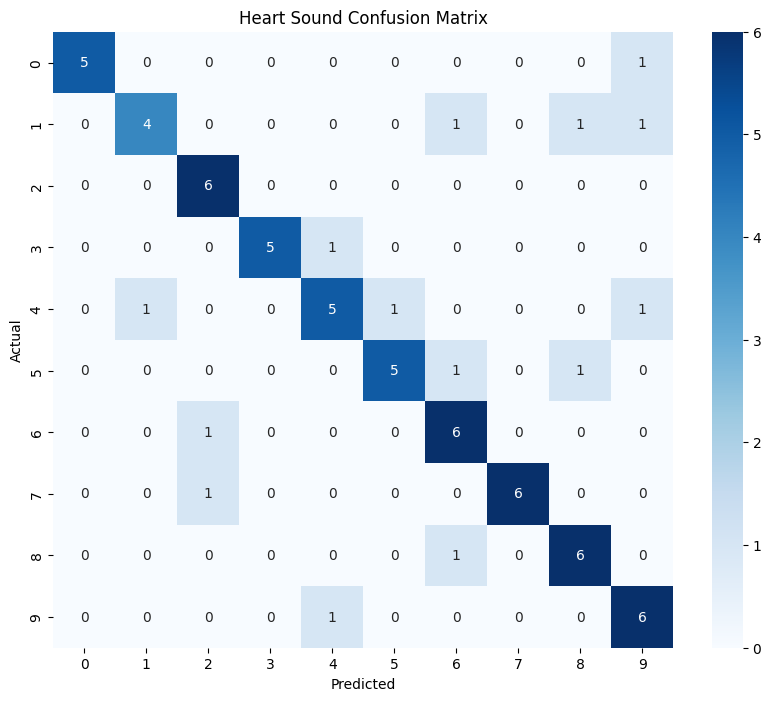

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Heart Sound Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=cnn_encoder.classes_
))

                       precision    recall  f1-score   support

             AV Block       1.00      0.83      0.91         6
  Atrial Fibrillation       0.80      0.57      0.67         7
Early Systolic Murmur       0.75      1.00      0.86         6
Late Diastolic Murmur       1.00      0.83      0.91         6
 Late Systolic Murmur       0.71      0.62      0.67         8
  Mid Systolic Murmur       0.83      0.71      0.77         7
               Normal       0.67      0.86      0.75         7
                   S3       1.00      0.86      0.92         7
                   S4       0.75      0.86      0.80         7
          Tachycardia       0.67      0.86      0.75         7

             accuracy                           0.79        68
            macro avg       0.82      0.80      0.80        68
         weighted avg       0.81      0.79      0.79        68



In [ ]:
def predict_heart(audio_path):

    spec = extract_spectrogram(audio_path)

    spec = np.array(spec)

    spec = spec[np.newaxis, ..., np.newaxis]

    spec = (spec - spec.mean()) / spec.std()

    pred = model.predict(spec)[0]

    pred_class = np.argmax(pred)

    disease = cnn_encoder.inverse_transform([pred_class])[0]

    confidence = pred[pred_class] * 100

    print("\n===== HEART DISEASE PREDICTION =====")
    print(f"Prediction: {disease}")
    print(f"Confidence: {confidence:.2f}%")

    print("\nClass Probabilities:\n")

    for i, prob in enumerate(pred):

        class_name = cnn_encoder.inverse_transform([i])[0]

        print(f"{class_name}: {prob*100:.2f}%")

    return disease

In [ ]:
predict_heart(df.iloc[0]["path"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

===== HEART DISEASE PREDICTION =====
Prediction: Normal
Confidence: 99.88%

Class Probabilities:

AV Block: 0.00%
Atrial Fibrillation: 0.00%
Early Systolic Murmur: 0.07%
Late Diastolic Murmur: 0.00%
Late Systolic Murmur: 0.00%
Mid Systolic Murmur: 0.00%
Normal: 99.88%
S3: 0.03%
S4: 0.01%
Tachycardia: 0.00%


np.str_('Normal')

In [ ]:
predict_heart("/content/M0001.wav")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

===== HEART DISEASE PREDICTION =====
Prediction: Late Systolic Murmur
Confidence: 98.89%

Class Probabilities:

AV Block: 0.00%
Atrial Fibrillation: 0.00%
Early Systolic Murmur: 0.00%
Late Diastolic Murmur: 0.05%
Late Systolic Murmur: 98.89%
Mid Systolic Murmur: 0.03%
Normal: 0.01%
S3: 0.00%
S4: 0.01%
Tachycardia: 1.00%


np.str_('Late Systolic Murmur')

In [ ]:
X_lung = []
y_lung_labels = []

for _, row in df.iterrows():

    # ONLY keep rows with REAL lung labels
    if row["lung_label"] != "None":

        spec = extract_spectrogram(row["path"])

        if spec is not None:

            X_lung.append(spec)
            y_lung_labels.append(row["lung_label"])

/tmp/ipykernel_5763/2746112817.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=22050)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
from sklearn.preprocessing import LabelEncoder

lung_encoder_cnn = LabelEncoder()

y_lung = lung_encoder_cnn.fit_transform(y_lung_labels)

In [ ]:
X_lung = np.array(X_lung)
y_lung = np.array(y_lung)

print(X_lung.shape)
print(y_lung.shape)

(325, 128, 128)
(325,)


In [ ]:
X_lung = X_lung[..., np.newaxis]

print(X_lung.shape)

(325, 128, 128, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_lung, X_test_lung, y_train_lung, y_test_lung = train_test_split(
    X_lung,
    y_lung,
    test_size=0.2,
    random_state=42,
    stratify=y_lung
)

In [ ]:
X_train_lung = X_train_lung.astype("float32")
X_test_lung = X_test_lung.astype("float32")

X_train_lung = (X_train_lung - X_train_lung.mean()) / X_train_lung.std()
X_test_lung = (X_test_lung - X_test_lung.mean()) / X_test_lung.std()

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

lung_model = Sequential([

    tf.keras.layers.Input(shape=(128,128,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Dropout(0.3),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.4),

    Dense(len(lung_encoder_cnn.classes_), activation='softmax')
])

In [ ]:
lung_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_lung_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [ ]:
history_lung = lung_model.fit(
    X_train_lung,
    y_train_lung,
    epochs=50,
    batch_size=8,
    validation_data=(X_test_lung, y_test_lung),

    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.1494 - loss: 1.9168

33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 289ms/step - accuracy: 0.1654 - loss: 1.8393 - val_accuracy: 0.2000 - val_loss: 1.7697
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.2436 - loss: 1.7542

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 329ms/step - accuracy: 0.2500 - loss: 1.7634 - val_accuracy: 0.2615 - val_loss: 1.7466
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.3750 - loss: 1.7202

33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 280ms/step - accuracy: 0.3731 - loss: 1.6806 - val_accuracy: 0.3538 - val_loss: 1.5012
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.5536 - loss: 1.3322

33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 348ms/step - accuracy: 0.5423 - loss: 1.2684 - val_accuracy: 0.6308 - val_loss: 0.9735
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6733 - loss: 0.8993

...

33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 309ms/step - accuracy: 0.8731 - loss: 0.4128 - val_accuracy: 0.8923 - val_loss: 0.3366
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.8863 - loss: 0.3305

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 320ms/step - accuracy: 0.8846 - loss: 0.3510 - val_accuracy: 0.9077 - val_loss: 0.2367
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 0.9000 - loss: 0.2521 - val_accuracy: 0.9077 - val_loss: 0.2602
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9369 - loss: 0.2210

33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 330ms/step - accuracy: 0.9385 - loss: 0.2057 - val_accuracy: 0.9231 - val_loss: 0.2136
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9772 - loss: 0.0770

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 322ms/step - accuracy: 0.9577 - loss: 0.1274 - val_accuracy: 0.9538 - val_loss: 0.1831
Epoch 13/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 247ms/step - accuracy: 0.9538 - loss: 0.1408 - val_accuracy: 0.9231 - val_loss: 0.1785
Epoch 14/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 325ms/step - accuracy: 0.9500 - loss: 0.1566 - val_accuracy: 0.9538 - val_loss: 0.2605
Epoch 15/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 309ms/step - accuracy: 0.9654 - loss: 0.1126 - val_accuracy: 0.9385 - val_loss: 0.1795
Epoch 16/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step - accuracy: 0.9654 - loss: 0.1207 - val_accuracy: 0.9538 - val_loss: 0.2003
Epoch 17/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 306ms/step - accuracy: 0.9731 - loss: 0.0797 - val_accuracy: 0.9538 - val_loss: 0.1222
Epoch 18/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9896 - loss: 0.0409

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 303ms/step - accuracy: 0.9846 - loss: 0.0427 - val_accuracy: 0.9692 - val_loss: 0.1796
Epoch 19/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.9769 - loss: 0.0521 - val_accuracy: 0.9231 - val_loss: 0.1910
Epoch 20/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 315ms/step - accuracy: 0.9962 - loss: 0.0566 - val_accuracy: 0.9538 - val_loss: 0.1587
Epoch 21/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 296ms/step - accuracy: 0.9885 - loss: 0.0544 - val_accuracy: 0.9538 - val_loss: 0.1697
Epoch 22/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 243ms/step - accuracy: 0.9846 - loss: 0.0607 - val_accuracy: 0.9231 - val_loss: 0.2139


In [ ]:
y_pred_probs_lung = lung_model.predict(X_test_lung)

y_pred_lung = np.argmax(y_pred_probs_lung, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 520ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_lung,
    y_pred_lung,
    target_names=lung_encoder_cnn.classes_
))

                 precision    recall  f1-score   support

Coarse Crackles       1.00      1.00      1.00         8
  Fine Crackles       0.89      0.89      0.89         9
         Normal       0.86      0.92      0.89        13
    Pleural Rub       1.00      0.92      0.96        12
        Rhonchi       1.00      1.00      1.00        11
       Wheezing       1.00      1.00      1.00        12

       accuracy                           0.95        65
      macro avg       0.96      0.95      0.96        65
   weighted avg       0.96      0.95      0.95        65



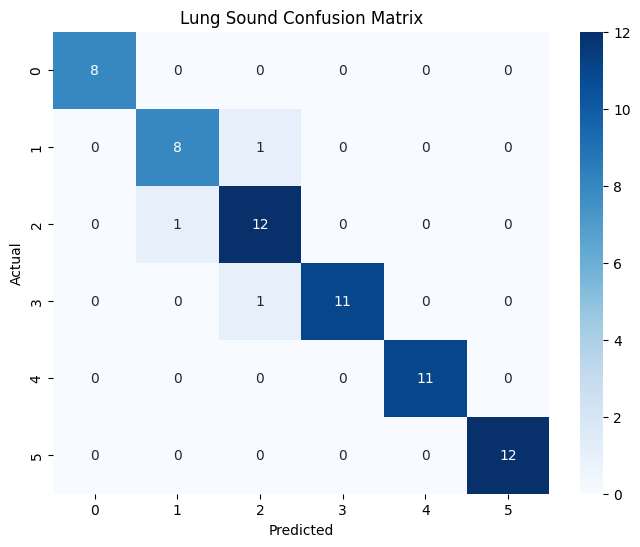

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_lung, y_pred_lung)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Lung Sound Confusion Matrix")

plt.show()

In [ ]:
lung_model.save("lung_cnn_model.keras")

In [ ]:
def predict_lung(audio_path):

    spec = extract_spectrogram(audio_path)

    spec = np.array(spec)

    spec = spec[np.newaxis, ..., np.newaxis]

    spec = (spec - spec.mean()) / spec.std()

    pred = lung_model.predict(spec)

    pred_class = np.argmax(pred)

    return lung_encoder_cnn.inverse_transform([pred_class])[0]

In [ ]:
predict_lung("/content/M0001.wav")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


np.str_('Rhonchi')